In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Corona_NLP_train.csv", encoding="latin-1")

In [3]:
df['OriginalTweet'].sample(5)

,OriginalTweet
22192,"In this crazy time, my job make us work more a..."
1864,The Push &amp; Pull of Covid-19. Whilst compan...
28283,Report on consumer spending during #coronaviru...
1351,COVID 19 ? - Sarawak Update \r\r\n\r\r\nLatest...
7484,Our partners at @NetElixir are using their kno...


In [4]:
x=df.iloc[:,4]
y=df.iloc[:,5]

In [5]:
import re

def clean_text(text):

    text = re.sub(r'@\w+', '', text)          # remove mentions
    text = re.sub(r'http\S+', '', text)       # remove urls
    text = re.sub(r'#\w+', '', text)          # remove hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove special chars
    text = text.lower()                       # lowercase

    return text

In [6]:
x=x.apply(clean_text)

In [7]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    new_text = []

    for word in text.split():
        if word not in stop_words:
            new_text.append(word)

    return " ".join(new_text)

In [9]:
x=x.apply(remove_stopwords)

In [10]:
x

,OriginalTweet
0,
1,advice talk neighbours family exchange phone n...
2,coronavirus australia woolworths give elderly ...
3,food stock one empty please dont panic enough ...
4,ready go supermarket outbreak im paranoid food...
...,...
41152,airline pilots offering stock supermarket shel...
41153,response complaint provided citing covid relat...
41154,know getting tough rationing toilet paper mart...
41155,wrong smell hand sanitizer starting turn


In [11]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(x)

In [12]:
word_index = tokenizer.word_index

In [13]:
len(word_index)

36720

In [14]:
sequences = tokenizer.texts_to_sequences(x)

In [15]:
sequences

[[],
 [380,
  731,
  2333,
  168,
  2632,
  737,
  1069,
  935,
  318,
  266,
  737,
  1069,
  2333,
  1057,
  3430,
  3259,
  4345,
  360,
  12,
  11,
  2118,
  10914,
  2864,
  103,
  886,
  2934,
  136],
 [25, 813, 4346, 202, 222, 1300, 1624, 11, 161, 77, 2, 60],
 [4, 28, 30, 126, 35, 32, 18, 146, 4, 67, 57, 14, 42, 818, 42, 83],
 [601,
  21,
  6,
  60,
  43,
  3751,
  4,
  28,
  17792,
  126,
  678,
  199,
  35,
  32,
  18,
  1502,
  326],
 [118,
  3260,
  98,
  1011,
  2,
  459,
  609,
  13226,
  715,
  104,
  76,
  8,
  9486,
  470,
  47,
  525,
  538,
  103,
  27,
  24,
  4,
  39,
  40,
  183,
  330],
 [1058, 7, 5, 1161, 688, 2738, 9487, 9488, 43, 17793, 1404, 55, 43, 803],
 [6, 45, 420, 48, 39, 40],
 [31,
  2,
  61,
  5,
  10915,
  5120,
  125,
  8447,
  89,
  2518,
  140,
  147,
  111,
  732,
  689,
  158,
  219,
  1365,
  12,
  737,
  392,
  267,
  86,
  2040],
 [312,
  17794,
  62,
  48,
  141,
  504,
  81,
  12,
  1197,
  3752,
  312,
  80,
  3084,
  68,
  2807,
  12,
  11,

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 30

padded_sequence = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [17]:
padded_sequence

array([[    0,     0,     0, ...,     0,     0,     0],
       [  380,   731,  2333, ...,     0,     0,     0],
       [   25,   813,  4346, ...,     0,     0,     0],
       ...,
       [   55,   127,  1408, ...,     0,     0,     0],
       [  573,  3747,    27, ...,     0,     0,     0],
       [  101, 36718, 36719, ...,     0,     0,     0]], dtype=int32)

In [18]:
lb=LabelEncoder()
y_trans=lb.fit_transform(y)

In [19]:
y_trans

array([3, 4, 4, ..., 4, 3, 2])

In [20]:
x_train,x_test,y_train,y_test=train_test_split(padded_sequence,y_trans,test_size=0.2,random_state=42)

In [21]:
x_train

array([[  858,  1211,   204, ...,     0,     0,     0],
       [ 1471,   170,    64, ...,     0,     0,     0],
       [28050,  2411,  6733, ...,     0,     0,     0],
       ...,
       [ 9488,  2865,    12, ...,     0,     0,     0],
       [  996,   115,  1374, ...,     0,     0,     0],
       [ 1430,  9179,     0, ...,     0,     0,     0]], dtype=int32)

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, RNN, LSTM

In [23]:
model1=Sequential()

In [24]:
vocab_size=len(word_index)+1
embedding_dim = 64
max_length = 30
num_classes = len(lb.classes_)

In [26]:
from tensorflow.keras.layers import Input

model1 = Sequential()

model1.add(Input(shape=(30,)))
model1.add(Embedding(vocab_size, embedding_dim))
model1.add(LSTM(64, return_sequences=True))
model1.add(LSTM(32))
model1.add(Dense(num_classes, activation='softmax'))

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │     2,350,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,395,749 (9.14 MB)

 Trainable params: 2,395,749 (9.14 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history1= model1.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 72s 65ms/step - accuracy: 0.3818 - loss: 1.3885 - val_accuracy: 0.6952 - val_loss: 0.8100
Epoch 2/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 73s 57ms/step - accuracy: 0.7762 - loss: 0.6361 - val_accuracy: 0.7617 - val_loss: 0.6812
Epoch 3/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.8695 - loss: 0.4151 - val_accuracy: 0.7579 - val_loss: 0.7064
Epoch 4/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 79s 53ms/step - accuracy: 0.9102 - loss: 0.3007 - val_accuracy: 0.7609 - val_loss: 0.7567
Epoch 5/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.9326 - loss: 0.2282 - val_accuracy: 0.7521 - val_loss: 0.8602


In [33]:
from tensorflow.keras.layers import SimpleRNN

model2 = Sequential()

model2.add(Input(shape=(30,)))
model2.add(Embedding(vocab_size, embedding_dim))
model2.add(SimpleRNN(64, return_sequences=True))
model2.add(SimpleRNN(32))
model2.add(Dense(num_classes, activation='softmax'))

model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 30, 64)         │     2,350,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 30, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,361,669 (9.01 MB)

 Trainable params: 2,361,669 (9.01 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
history2= model1.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 56s 54ms/step - accuracy: 0.9441 - loss: 0.1918 - val_accuracy: 0.7511 - val_loss: 0.8924
Epoch 2/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 56s 55ms/step - accuracy: 0.9555 - loss: 0.1638 - val_accuracy: 0.7364 - val_loss: 1.0186
Epoch 3/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 57s 56ms/step - accuracy: 0.9631 - loss: 0.1307 - val_accuracy: 0.7292 - val_loss: 1.0501
Epoch 4/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 54s 53ms/step - accuracy: 0.9696 - loss: 0.1096 - val_accuracy: 0.7346 - val_loss: 1.0942
Epoch 5/5
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 54s 53ms/step - accuracy: 0.9735 - loss: 0.0971 - val_accuracy: 0.7269 - val_loss: 1.1603


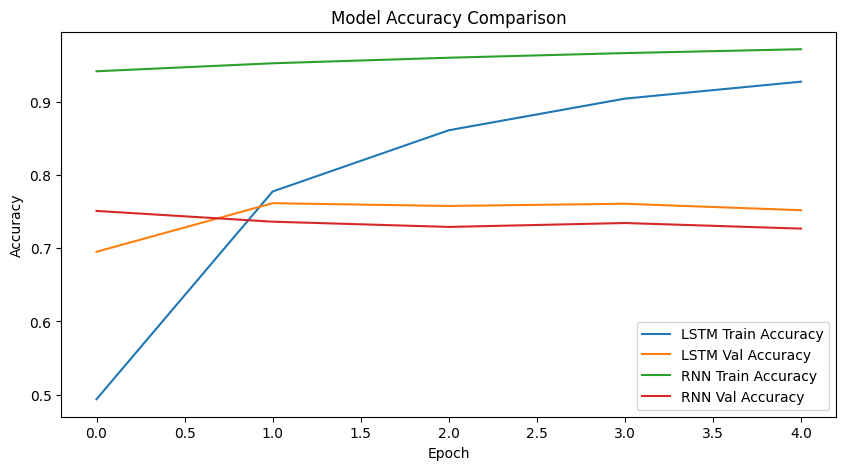

In [38]:
plt.figure(figsize=(10,5))

plt.plot(history1.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='LSTM Val Accuracy')

plt.plot(history2.history['accuracy'], label='RNN Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='RNN Val Accuracy')

plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

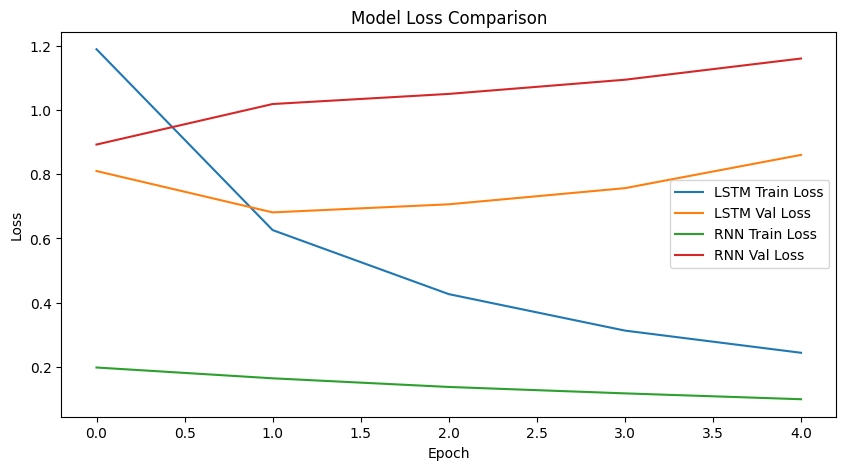

In [39]:
plt.figure(figsize=(10,5))

plt.plot(history1.history['loss'], label='LSTM Train Loss')
plt.plot(history1.history['val_loss'], label='LSTM Val Loss')

plt.plot(history2.history['loss'], label='RNN Train Loss')
plt.plot(history2.history['val_loss'], label='RNN Val Loss')

plt.title("Model Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()